Импортирую нужные библиотеки

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda')

Оглашаю функцию, способную генерировать случайные белые области на изображении и шум

In [49]:
def corrupt(x, target_area_pct=0.15, area_tol=0.05, target_noise_lvl=0.3, noise_tol=0.05):
    x = x.clone()
    c, h, w = x.shape

    if target_noise_lvl > 0:
        noise_lvl = target_noise_lvl + (torch.rand(1).item() - 0.5) * 2 * noise_tol
        x = torch.clamp(x + torch.randn_like(x) * noise_lvl, -1.0, 1.0)

    target_px = target_area_pct * h * w
    min_px = target_px * (1 - area_tol)
    max_px = target_px * (1 + area_tol)
    
    while True:
        mh = torch.randint(8, int(h * 0.45), (1,)).item()
        mw = torch.randint(8, int(w * 0.45), (1,)).item()
        if min_px <= mh * mw <= max_px:
            break
            
    y = torch.randint(0, h - mh + 1, (1,)).item()
    xp = torch.randint(0, w - mw + 1, (1,)).item()
    x[:, y:y+mh, xp:xp+mw] = 1.0

    return x

Класс датасета с изображениями знаменитостей

In [ ]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, size=128, subsample=None, 
                 target_area_pct=0.15, area_tol=0.05, 
                 target_noise_lvl=0.3, noise_tol=0.05):
        self.root = Path(root_dir)
        self.imgs = list(self.root.glob('*.jpg'))
        if subsample: self.imgs = self.imgs[:subsample]
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.cfg_corrupt = {
            'target_area_pct': target_area_pct, 'area_tol': area_tol,
            'target_noise_lvl': target_noise_lvl, 'noise_tol': noise_tol
        }

    def __len__(self):
        return len(self.imgs)
    
    def __getitem__(self, idx):
        img = Image.open(self.imgs[idx]).convert('RGB')
        clean = self.transform(img)
        return corrupt(clean, **self.cfg_corrupt), clean

Создаю конфиг для централизованного контроля параметров

In [51]:
CFG = {
    'data_root': 'data/celeba/img_align_celeba',
    'img_size': 128,
    'batch_size': 64,
    'epochs': 40,
    'lr': 5e-4,
    'subsample': 5000,
    'target_area_pct': 0.1,
    'area_tol': 0.05,
    'target_noise_lvl': 0.05,
    'noise_tol': 0.02
}

Класс автоэнкодера для "восстановления" изображений

In [52]:
class UNet(nn.Module):
    def __init__(self, in_ch=3):
        super().__init__()
        self.e1 = nn.Sequential(nn.Conv2d(in_ch, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        self.p1 = nn.MaxPool2d(2)
        self.e2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        self.p2 = nn.MaxPool2d(2)
        self.e3 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU())
        self.p3 = nn.MaxPool2d(2)
        self.bot = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU())

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.d3 = nn.Sequential(nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU())
        
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.d2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU())
        
        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.d1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
        
        self.out = nn.Sequential(nn.Conv2d(64, in_ch, 3, padding=1), nn.Tanh())
        
    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.p1(e1))
        e3 = self.e3(self.p2(e2))
        b = self.bot(self.p3(e3))
        
        d3 = self.d3(torch.cat([self.up3(b), e3], 1))
        d2 = self.d2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.d1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)

Оглашаю функцию подготовки даталоадеров

In [53]:
def get_loaders(cfg):
    ds = CelebADataset(
        cfg['data_root'], 
        size=cfg['img_size'], 
        subsample=cfg['subsample'],
        target_area_pct=cfg['target_area_pct'],
        area_tol=cfg['area_tol'],
        target_noise_lvl=cfg['target_noise_lvl'],
        noise_tol=cfg['noise_tol']
    )
    train_len = int(len(ds) * 0.9)
    val_len = len(ds) - train_len
    train_ds, val_ds = random_split(ds, [train_len, val_len])
    
    return DataLoader(train_ds, cfg['batch_size'], True, num_workers=0, pin_memory=True), \
           DataLoader(val_ds, cfg['batch_size'], num_workers=0, pin_memory=True)

Оглашаю функцию тренировки

In [54]:
def train_epoch(mdl, ld, opt, crit, dev):
    mdl.train(); tl = 0
    bar = tqdm(ld, leave=False, desc='Training')
    for xc, xg in bar:
        xc, xg = xc.to(dev), xg.to(dev)
        opt.zero_grad()
        loss = crit(mdl(xc), xg)
        loss.backward(); opt.step()
        tl += loss.item()
        bar.set_postfix({'loss': f'{loss.item():.4f}'})
    return tl / len(ld)

Оглашаю функцию валидации

In [ ]:
def validate(mdl, ld, crit, dev):
    mdl.eval(); tl, p, s = 0, [], []
    with torch.no_grad():
        for xc, xg in tqdm(ld, leave=False, desc='Validating'):
            xc, xg = xc.to(dev), xg.to(dev)
            out = mdl(xc)
            tl += crit(out, xg).item()
            for i in range(len(xg)):
                pred = out[i].permute(1,2,0).cpu().numpy()
                gt = xg[i].permute(1,2,0).cpu().numpy()
                pred = (pred * 0.5) + 0.5
                gt = (gt * 0.5) + 0.5
                p.append(psnr(gt, np.clip(pred, 0, 1), data_range=1.0))
                s.append(ssim(gt, np.clip(pred, 0, 1), data_range=1.0, channel_axis=2, multichannel=True))
    return tl/len(ld), np.mean(p), np.mean(s)

Оглашаю функцию запуска экспериментов

In [ ]:
def run_training(mdl, tr_ld, va_ld, cfg):
    mdl = mdl.to(device)
    opt = optim.Adam(mdl.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    crit = nn.SmoothL1Loss() 

    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'])
    
    hist = {'tl':[], 'vl':[], 'psnr':[], 'ssim':[]}
    
    bar = tqdm(range(cfg['epochs']), desc='Epochs')
    for ep in bar:
        tl = train_epoch(mdl, tr_ld, opt, crit, device)
        vl, p, s = validate(mdl, va_ld, crit, device)

        scheduler.step() 
        
        hist['tl'].append(tl); hist['vl'].append(vl)
        hist['psnr'].append(p); hist['ssim'].append(s)
        bar.set_postfix({'Loss': f'{vl:.4f}', 'PSNR': f'{p:.2f}dB', 'SSIM': f'{s:.3f}'})
        
    return mdl, hist

Подготавливаю данные

In [57]:
train_ld, val_ld = get_loaders(CFG)
print(f"Train: {len(train_ld.dataset)}, Val: {len(val_ld.dataset)}")

Train: 4500, Val: 500


Промежуточный вывод примеров "искажений" на фото

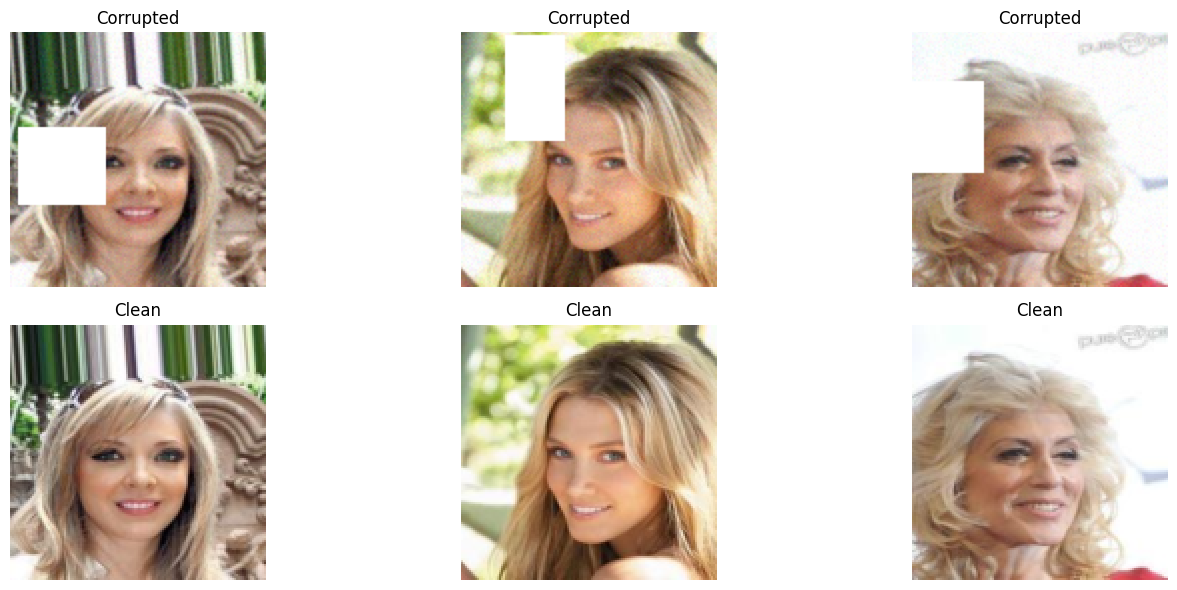

In [58]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
xb, yb = next(iter(train_ld))

for i in range(3):
    cor = (xb[i].permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5
    clean = (yb[i].permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5

    ax[0, i].imshow(np.clip(cor, 0, 1))
    ax[0, i].set_title('Corrupted'); ax[0, i].axis('off')
    ax[1, i].imshow(np.clip(clean, 0, 1))
    ax[1, i].set_title('Clean'); ax[1, i].axis('off')

plt.tight_layout(); plt.show()

Создание и обучение модели

In [59]:
model = UNet()
model, history = run_training(model, train_ld, val_ld, CFG)

Epochs: 100%|██████████| 40/40 [12:24<00:00, 18.60s/it, Loss=0.0044, PSNR=27.47dB, SSIM=0.899]


Вывод графиков обучения

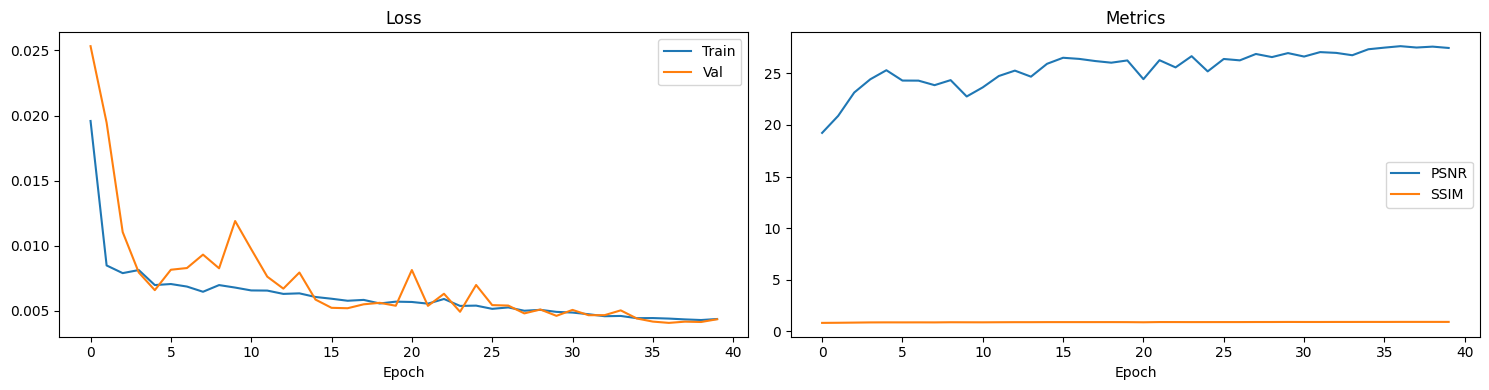

In [60]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.plot(history['tl'], label='Train')
plt.plot(history['vl'], label='Val')
plt.title('Loss'); plt.legend(); plt.xlabel('Epoch')

plt.subplot(1,2,2)
plt.plot(history['psnr'], label='PSNR')
plt.plot(history['ssim'], label='SSIM')
plt.title('Metrics'); plt.legend(); plt.xlabel('Epoch')
plt.tight_layout(); plt.show()

Визуализирую результаты

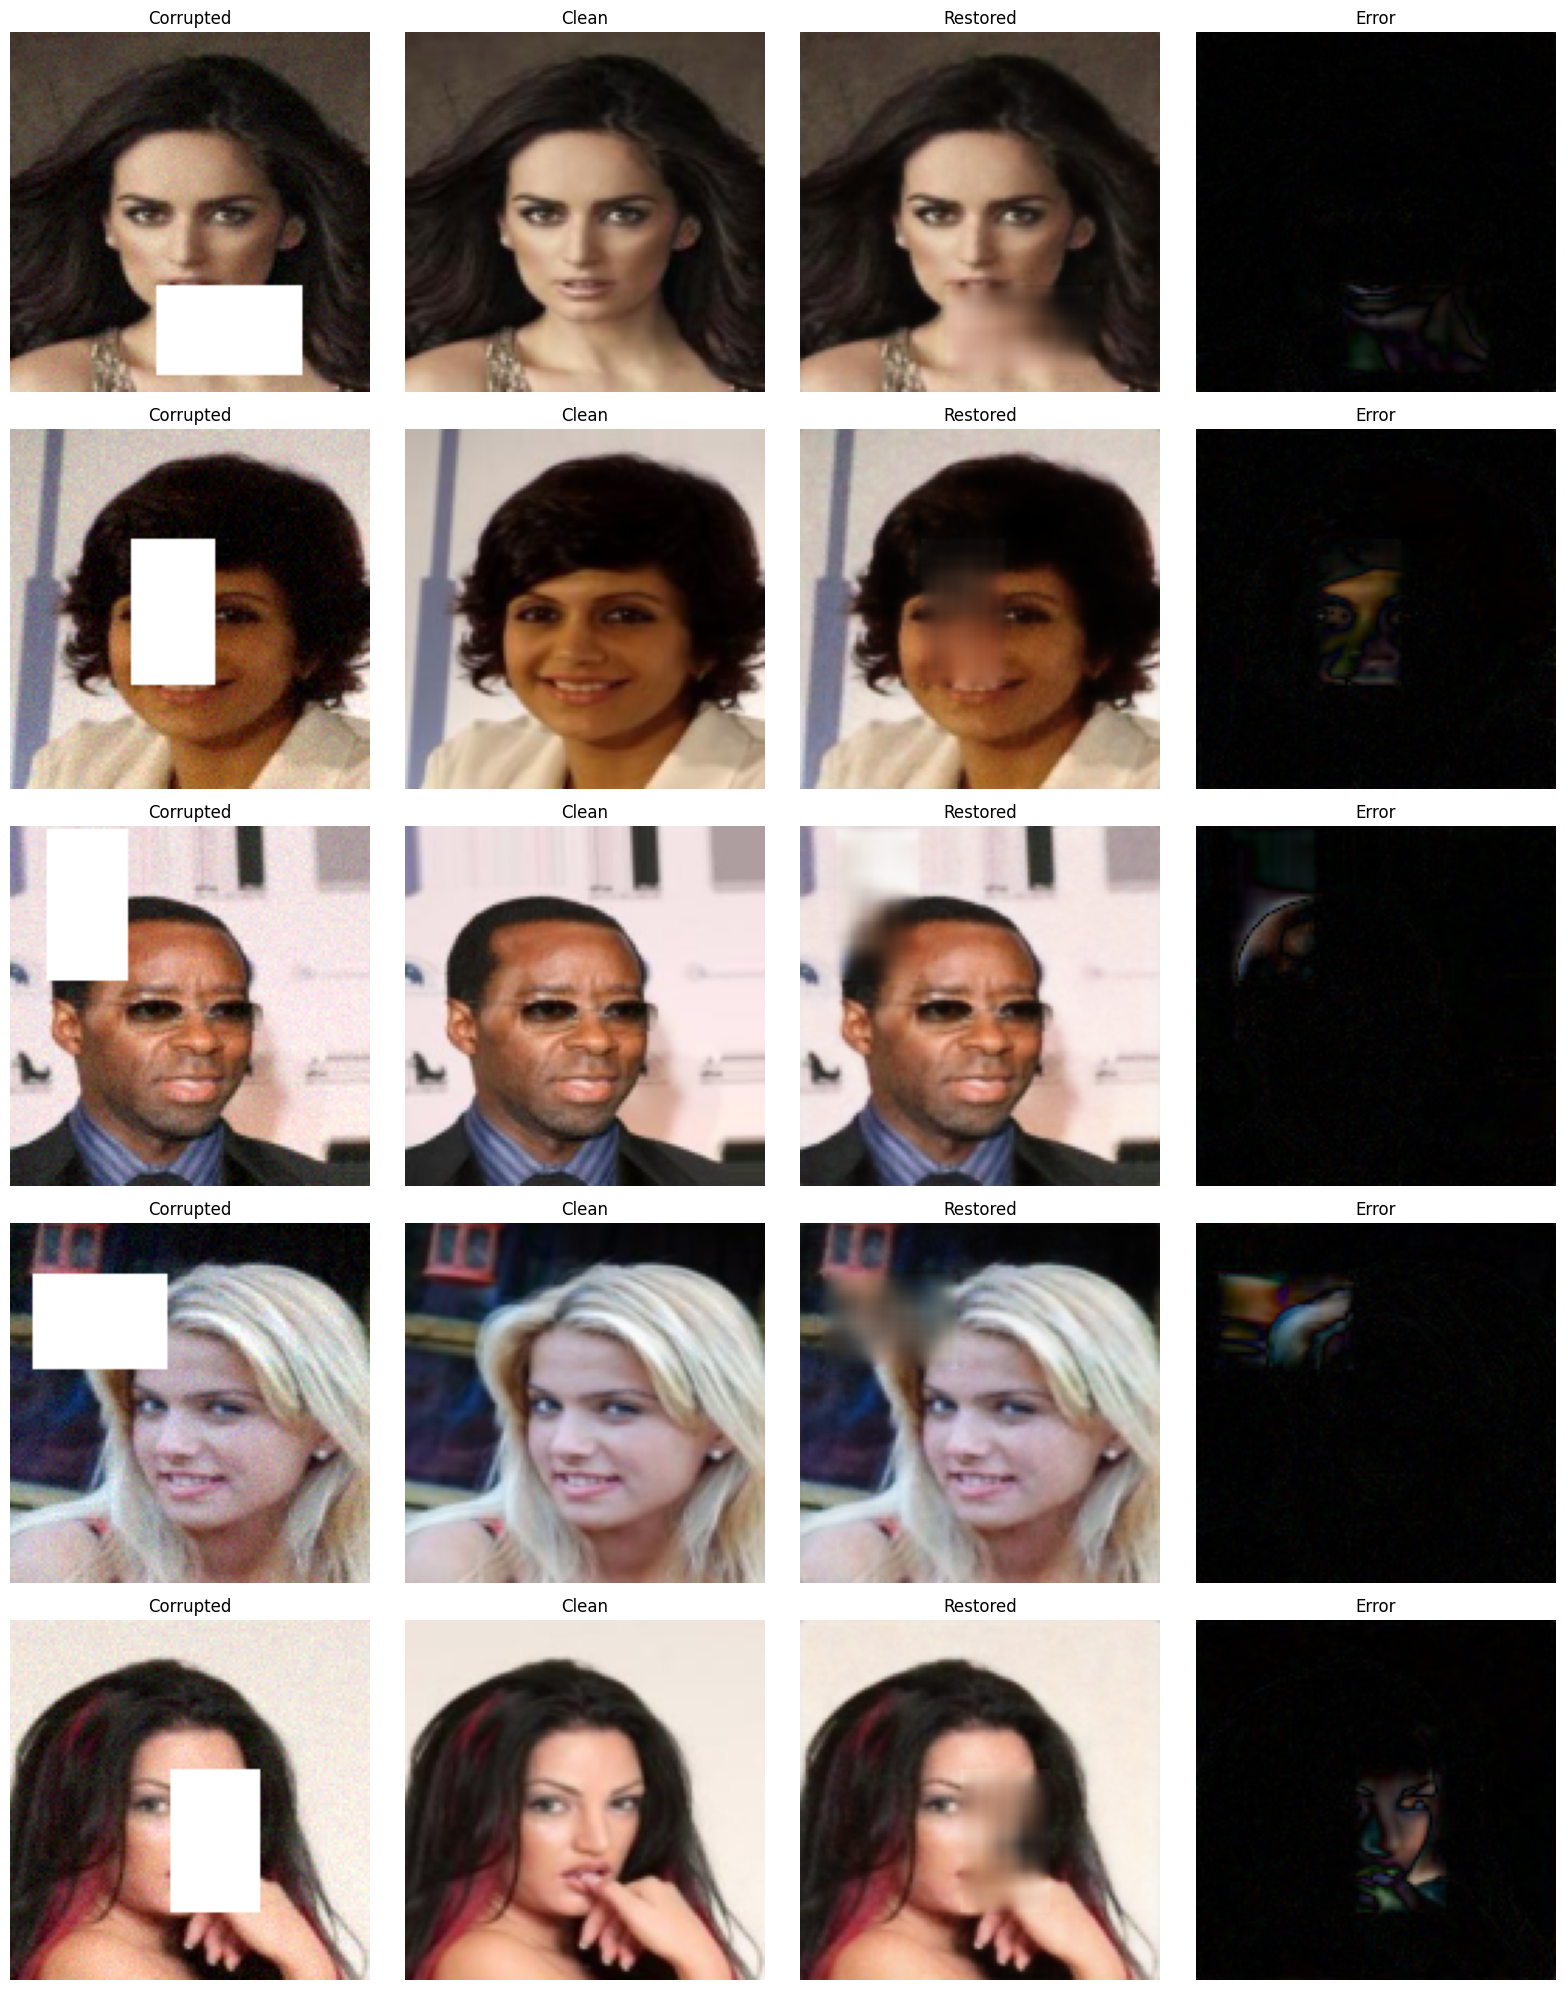

In [ ]:
def visualize_results(mdl, ld, dev, n=5):
    mdl.eval()
    fig, ax = plt.subplots(n, 4, figsize=(16, 4*n))
    
    with torch.no_grad():
        count = 0
        for batch_idx, (xc, xg) in enumerate(ld):
            if count >= n: break
            
            xc, xg = xc.to(dev), xg.to(dev)
            out = mdl(xc)

            for k in range(min(len(xc), n - count)):
                idx = count
                xc_vis = (xc[k].permute(1,2,0).cpu().numpy() * 0.5) + 0.5
                xg_vis = (xg[k].permute(1,2,0).cpu().numpy() * 0.5) + 0.5
                out_vis = (out[k].permute(1,2,0).cpu().numpy() * 0.5) + 0.5
                err_vis = np.abs(out_vis - xg_vis)
                
                for j, (img, title) in enumerate([(xc_vis, 'Corrupted'), (xg_vis, 'Clean'), 
                                                   (out_vis, 'Restored'), (err_vis, 'Error')]):
                    ax[idx, j].imshow(np.clip(img, 0, 1))
                    ax[idx, j].set_title(title)
                    ax[idx, j].axis('off')
                
                count += 1
                if count >= n: break
                
    plt.tight_layout()
    plt.show()

visualize_results(model, val_ld, device)

Оцениваю итоговые метрики модели

In [ ]:
model.eval()
with torch.no_grad():
    psnrs, ssims = [], []
    for xc, xg in tqdm(val_ld, desc='Final eval'):
        xc, xg = xc.to(device), xg.to(device)
        out = model(xc)
        for i in range(len(xg)):
            pred = (out[i].permute(1,2,0).cpu().numpy() * 0.5) + 0.5
            gt = (xg[i].permute(1,2,0).cpu().numpy() * 0.5) + 0.5
            psnrs.append(psnr(gt, np.clip(pred, 0, 1), data_range=1.0))
            ssims.append(ssim(gt, np.clip(pred, 0, 1), data_range=1.0, channel_axis=2, multichannel=True))

Final eval: 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]


In [64]:
print(f"PSNR: {np.mean(psnrs):.2f} ± {np.std(psnrs):.2f} dB")
print(f"SSIM: {np.mean(ssims):.4f} ± {np.std(ssims):.4f}")

PSNR: 27.73 ± 2.51 dB
SSIM: 0.8999 ± 0.0218
